In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = pd.read_csv('../data/final_normalized_data_for_ML.csv')
X = data.drop(columns=['HALE_Birth'])
y = data['HALE_Birth']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 8880 samples
Testing set size: 2220 samples


In [4]:
# Dictionary to store model performance results
model_results = {}

In [5]:
# 1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)
mse_train_lr = mean_squared_error(y_train, y_train_pred_lr)
r2_train_lr = r2_score(y_train, y_train_pred_lr)
mse_test_lr = mean_squared_error(y_test, y_test_pred_lr)
r2_test_lr = r2_score(y_test, y_test_pred_lr)
model_results['Linear Regression'] = {
    'Train MSE': mse_train_lr, 'Train R²': r2_train_lr,
    'Test MSE': mse_test_lr, 'Test R²': r2_test_lr
}

print("Linear Regression:")
print(f"Train MSE: {mse_train_lr}, Train R²: {r2_train_lr}")
print(f"Test MSE: {mse_test_lr}, Test R²: {r2_test_lr}")

Linear Regression:
Train MSE: 0.017819181022396467, Train R²: 0.9819328821598373
Test MSE: 0.021341300541216027, Test R²: 0.9797459059821207


In [6]:
# 2. Random Forest Regressor with Tuning to Prevent Overfitting
rf_model = RandomForestRegressor(
    n_estimators=50,          # Reduce the number of trees
    max_depth=10,             # Limit the depth of the tree to prevent overfitting
    min_samples_split=10,     # Require more samples to split a node
    oob_score=True,           # Enable out-of-bag samples for validation
    random_state=42           # Set random state for reproducibility
)

# Train the Random Forest model with tuned hyperparameters
rf_model.fit(X_train, y_train)

# Make predictions on both the training set and the test set
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Calculate Mean Squared Error (MSE) and R² score for both training and test sets
mse_train_rf = mean_squared_error(y_train, y_train_pred_rf)
r2_train_rf = r2_score(y_train, y_train_pred_rf)
mse_test_rf = mean_squared_error(y_test, y_test_pred_rf)
r2_test_rf = r2_score(y_test, y_test_pred_rf)

# Store the results in the model_results dictionary
model_results['Random Forest'] = {
    'Train MSE': mse_train_rf, 
    'Train R²': r2_train_rf,
    'Test MSE': mse_test_rf, 
    'Test R²': r2_test_rf,
}

# Display the results for Random Forest
print("Random Forest Model Results:")
print(f"Train MSE: {mse_train_rf}, Train R²: {r2_train_rf}")
print(f"Test MSE: {mse_test_rf}, Test R²: {r2_test_rf}")

# Ensure OOB Score is printed if applicable
if rf_model.oob_score:
    print(f"OOB Score: {rf_model.oob_score_}")  # OOB Score for generalization check

Random Forest Model Results:
Train MSE: 0.009765316254284355, Train R²: 0.9900988087336415
Test MSE: 0.014770725203757128, Test R²: 0.9859817513739906
OOB Score: 0.9832631779104832


In [7]:
# 3. Gradient Boosting Regressor
gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(X_train, y_train)
y_train_pred_gbr = gbr_model.predict(X_train)
y_test_pred_gbr = gbr_model.predict(X_test)
mse_train_gbr = mean_squared_error(y_train, y_train_pred_gbr)
r2_train_gbr = r2_score(y_train, y_train_pred_gbr)
mse_test_gbr = mean_squared_error(y_test, y_test_pred_gbr)
r2_test_gbr = r2_score(y_test, y_test_pred_gbr)
model_results['Gradient Boosting'] = {
    'Train MSE': mse_train_gbr, 'Train R²': r2_train_gbr,
    'Test MSE': mse_test_gbr, 'Test R²': r2_test_gbr
}

print("Gradient Boosting Regressor:")
print(f"Train MSE: {mse_train_gbr}, Train R²: {r2_train_gbr}")
print(f"Test MSE: {mse_test_gbr}, Test R²: {r2_test_gbr}")

Gradient Boosting Regressor:
Train MSE: 0.02478617902727345, Train R²: 0.9748689450581218
Test MSE: 0.028326112821187997, Test R²: 0.973116926443476


In [8]:
# Display model comparison results
model_comparison = pd.DataFrame(model_results).T
print(model_comparison)

                   Train MSE  Train R²  Test MSE   Test R²
Linear Regression   0.017819  0.981933  0.021341  0.979746
Random Forest       0.009765  0.990099  0.014771  0.985982
Gradient Boosting   0.024786  0.974869  0.028326  0.973117


<Figure size 1000x600 with 0 Axes>

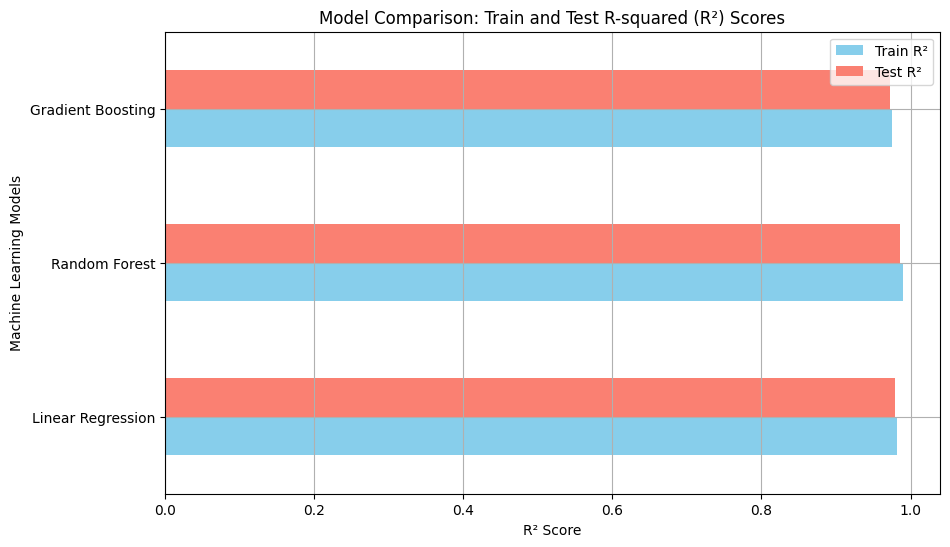

In [9]:
plt.figure(figsize=(10, 6))
model_comparison[['Train R²', 'Test R²']].plot(kind='barh', figsize=(10, 6), color=['skyblue', 'salmon'])
plt.title("Model Comparison: Train and Test R-squared (R²) Scores")
plt.xlabel("R² Score")
plt.ylabel("Machine Learning Models")
plt.grid(True)
plt.show()

<Figure size 1000x600 with 0 Axes>

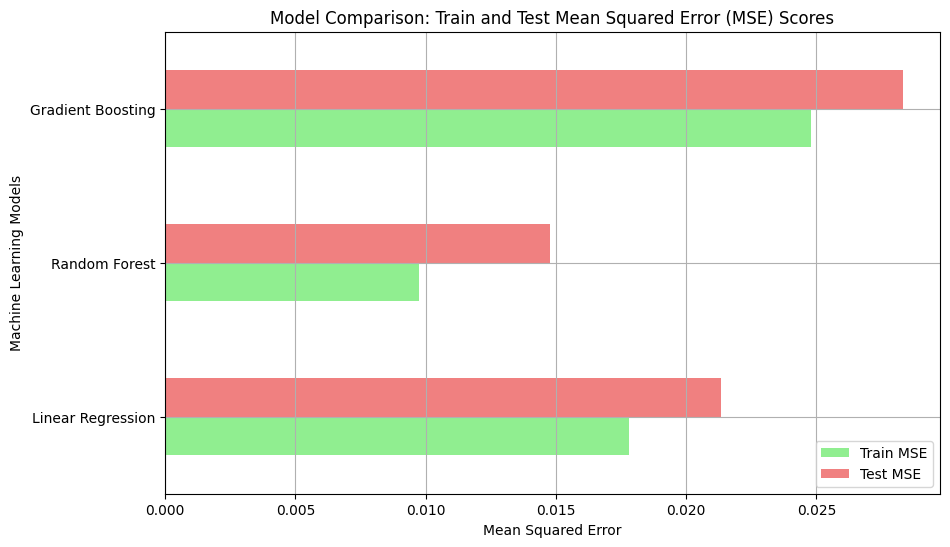

In [10]:
# Plot comparison of MSE scores for training and test sets
plt.figure(figsize=(10, 6))
model_comparison[['Train MSE', 'Test MSE']].plot(kind='barh', figsize=(10, 6), color=['lightgreen', 'lightcoral'])
plt.title("Model Comparison: Train and Test Mean Squared Error (MSE) Scores")
plt.xlabel("Mean Squared Error")
plt.ylabel("Machine Learning Models")
plt.grid(True)
plt.show()

                                              Feature  Importance
1                                             HALE_60    0.848157
5   Probability of dying between the exact ages 30...    0.099986
6   Estimates of rate of homicides (per 100 000 po...    0.006721
11                                     PM2.5_Exposure    0.006113
3   Age-standardized suicide rates (per 100 000 po...    0.004811
2   infant mortality rate (between birth and 11 mo...    0.004678
16                            ParentLocation_Americas    0.003972
9   Prevalence of obesity among adults, BMI ³ 30 (...    0.003155
8   Prevalence of insufficient physical activity a...    0.002558
4   Alcohol, total per capita (15+ years) consumpt...    0.002550


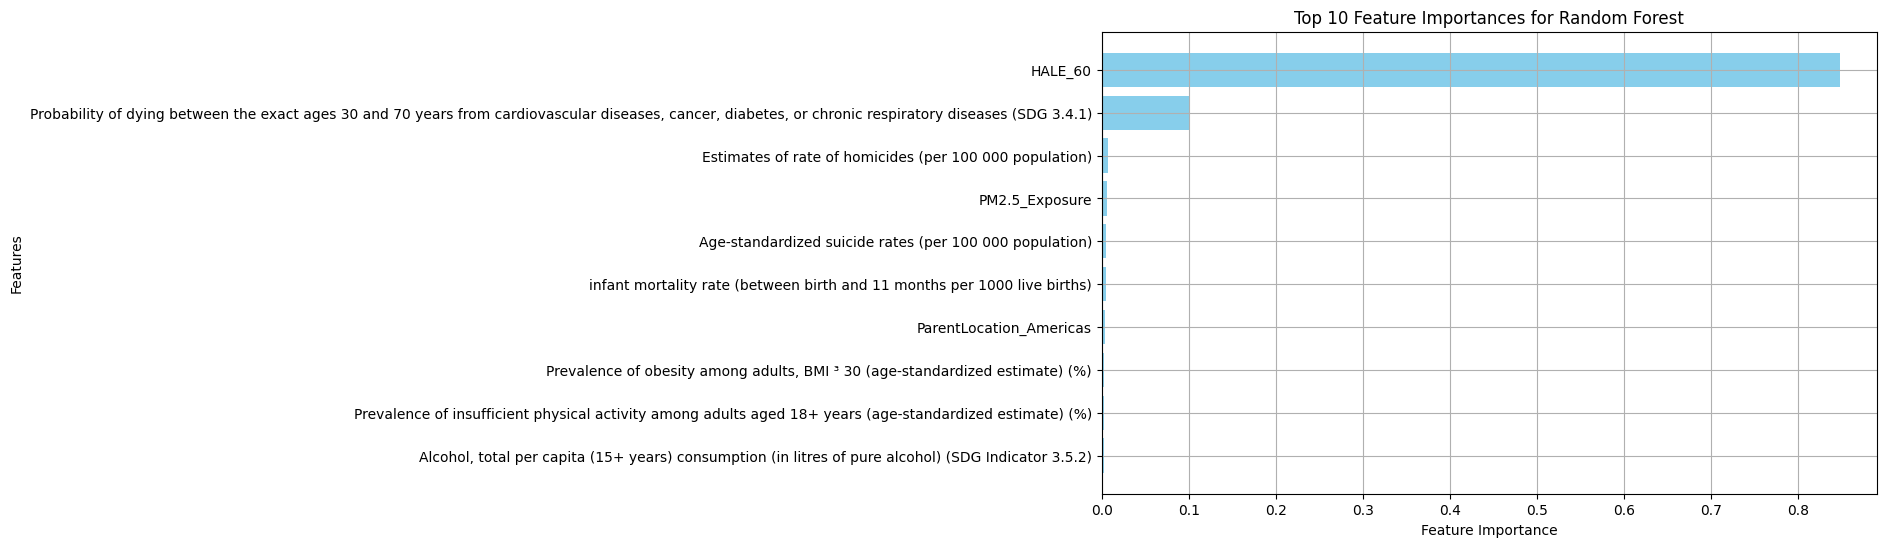

In [11]:
# Calculate feature importance for Random Forest
rf_feature_importance = rf_model.feature_importances_

# Create a DataFrame to display feature importance
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_feature_importance
}).sort_values(by='Importance', ascending=False)

# Display top 10 most important features
print(feature_importance_df.head(10))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10], color='skyblue')
plt.title('Top 10 Feature Importances for Random Forest')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()